# Tasks

4.1 predict magnitude of antibody response - H1N1 A/Victoria/4897/2022 (D28)

4.2 predict magnitude of antibody response - H3N2 A/Massachusetts/18/2022 (D28)

4.3 predict magnitude of antibody response - Vic B/Austria/1359417/2021 (D28)

4.4 predict magnitude of antibody response - all 3 vaccine strains (D28)

**4.5 predict antibody breadth - all variants (D28)**
* Training Data: Demographics + Day 0 + Day 7 innate
* Assay: HAI
* Measure: Geo mean
* Metric: Spearman correlation
* Full description: Geomean HAI across all variants

4.6 predict antibody breadth - all variants (D28)

4.7 predict antibody durability - H1N1 A/Victoria/4897/2022 (D365)

4.8 predict antibody durability - H3N2 A/Massachusetts/18/2022 (D365)

4.9 predict antibody durability - Vic B/Austria/1359417/2021 (D365)

4.10 predict antibody durability - all 3 vaccine strains (D365)

## Task 4.5: Focus
Breadth refers to how widely an antibody response covers different variants of a pathogen (not just the specific strain, but also related versions).
Want to measure a person's antibody response broadly, so we are predicting the 'average protective coverage' across the whole panel of flu variants.
Use the geometric mean (average used for antibody titers)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import gmean, spearmanr
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.pipeline import Pipeline

In [2]:
DATA_PATH = 'data/PART2-26-01-26_reorg/PART2-26-01-26_reorg'
train_hai = pd.read_csv(DATA_PATH + '/train_hai.tsv', sep='\t')
train_participants = pd.read_csv(DATA_PATH + '/train_participants.tsv', sep='\t')

In [3]:
for name, df in {'train_hai': train_hai, 'train_participants': train_participants}.items():
    print(f"\n{'=' * 50}")
    print(f'TABLE: {name}')
    print(f"{'=' * 50}")
    display(df.head(5))


TABLE: train_hai


,hai_id,participant_id,timepoint,virus_strain,value,material
0,ID_001__2016_UGA_Standard_Fluzone__0__HAI__H1N...,2016_UGA.ID_001,0.0,H1N1 A/South Carolina/1/1918,20.,Unknown
1,ID_001__2016_UGA_Standard_Fluzone__21__HAI__H1...,2016_UGA.ID_001,28.0,H1N1 A/South Carolina/1/1918,40.,Unknown
2,ID_002__2016_UGA_Standard_Fluzone__0__HAI__H1N...,2016_UGA.ID_002,0.0,H1N1 A/South Carolina/1/1918,5.,Unknown
3,ID_002__2016_UGA_Standard_Fluzone__21__HAI__H1...,2016_UGA.ID_002,28.0,H1N1 A/South Carolina/1/1918,5.,Unknown
4,ID_003__2016_UGA_Standard_Fluzone__0__HAI__H1N...,2016_UGA.ID_003,0.0,H1N1 A/South Carolina/1/1918,80.,Unknown



TABLE: train_participants


,participant_id,subject,biological_sex,race,min_age,max_age,geolocation,investigation_id,investigation_name,arm_id,arm_name,data_source,description,basic_curation,pubmed_ids,main_pmid,main_publication_author
0,SDY269.SUB112836,SUB112836,female,White,28,28,US: Georgia,SDY269,Systems Biology of 2008 Influenza Vaccination ...,ARM1888,LAIV group 2008,"ImmPort, ImmuneSpace",Healthy adults given 2008 LAIV vaccine,no,21743478 26682988,21743478,Nakaya HI (2011)
1,SDY269.SUB112849,SUB112849,female,Black or African American,39,39,US: Georgia,SDY269,Systems Biology of 2008 Influenza Vaccination ...,ARM1888,LAIV group 2008,"ImmPort, ImmuneSpace",Healthy adults given 2008 LAIV vaccine,no,21743478 26682988,21743478,Nakaya HI (2011)
2,SDY269.SUB112854,SUB112854,male,Black or African American,46,46,US: Georgia,SDY269,Systems Biology of 2008 Influenza Vaccination ...,ARM1888,LAIV group 2008,"ImmPort, ImmuneSpace",Healthy adults given 2008 LAIV vaccine,no,21743478 26682988,21743478,Nakaya HI (2011)
3,SDY269.SUB112860,SUB112860,female,White,32,32,US: Georgia,SDY269,Systems Biology of 2008 Influenza Vaccination ...,ARM1888,LAIV group 2008,"ImmPort, ImmuneSpace",Healthy adults given 2008 LAIV vaccine,no,21743478 26682988,21743478,Nakaya HI (2011)
4,SDY269.SUB112881,SUB112881,female,Black or African American,29,29,US: Georgia,SDY269,Systems Biology of 2008 Influenza Vaccination ...,ARM1888,LAIV group 2008,"ImmPort, ImmuneSpace",Healthy adults given 2008 LAIV vaccine,no,21743478 26682988,21743478,Nakaya HI (2011)


### Data Cleaning
HAI
* Timepoint column only missing 1.89% of values, and value column missing 0.02% of values. We decide to drop these rows.
* We also make sure the value column is numeric.

Participants
* main_publication_author missing 47.55% of values, geolocation missing 20.18%, pubmed_ids missing 3.06%, main_pmid missing 3.06%
* We drop the publication column all together. Will address other missing values depending on task.

In [4]:
# --- Clean HAI ---
# Drop rows missing timepoint or value (small % of data)
train_hai = train_hai.dropna(subset=['timepoint', 'value'])
# Coerce value to numeric; rows that can't convert become NaN
train_hai['value'] = pd.to_numeric(train_hai['value'], errors='coerce')
# Drop any new NaNs introduced by coercion
train_hai = train_hai.dropna(subset=['value'])
# Remove placeholder strain entries
train_hai = train_hai[train_hai['virus_strain'] != '-']

# --- Clean Participants ---
train_participants = train_participants.drop(columns=['main_publication_author'])
# Normalize categorical fields
train_participants['biological_sex'] = train_participants['biological_sex'].str.lower().str.strip()
train_participants['race'] = train_participants['race'].replace({
    'race: unknown': 'Unknown',
    'race: other': 'Unknown',
})

In [5]:
hai_cols_to_keep = [
    'hai_id', 'participant_id', 'timepoint', 'virus_strain', 'value'
]
# Drop geolocation since it's missing ~20% of the data and not needed for this task
participant_cols_to_keep = [
    'participant_id', 'biological_sex', 'race', 'min_age',
    'investigation_id', 'investigation_name', 'arm_id', 'arm_name',
    'data_source', 'description'
]

train_merged = train_hai[hai_cols_to_keep].merge(
    train_participants[participant_cols_to_keep],
    on='participant_id',
    how='left'
)

train_merged = train_merged.dropna()
train_merged.head()

,hai_id,participant_id,timepoint,virus_strain,value,biological_sex,race,min_age,investigation_id,investigation_name,arm_id,arm_name,data_source,description
0,ID_001__2016_UGA_Standard_Fluzone__0__HAI__H1N...,2016_UGA.ID_001,0.0,H1N1 A/South Carolina/1/1918,20.0,female,Unknown,29,2016_UGA,2016_UGA_Fluzone,2016_UGA_Standard_Fluzone,2016 UGA Standard Fluzone,UGA,2016 UGA Standard Fluzone
1,ID_001__2016_UGA_Standard_Fluzone__21__HAI__H1...,2016_UGA.ID_001,28.0,H1N1 A/South Carolina/1/1918,40.0,female,Unknown,29,2016_UGA,2016_UGA_Fluzone,2016_UGA_Standard_Fluzone,2016 UGA Standard Fluzone,UGA,2016 UGA Standard Fluzone
2,ID_002__2016_UGA_Standard_Fluzone__0__HAI__H1N...,2016_UGA.ID_002,0.0,H1N1 A/South Carolina/1/1918,5.0,female,Unknown,29,2016_UGA,2016_UGA_Fluzone,2016_UGA_Standard_Fluzone,2016 UGA Standard Fluzone,UGA,2016 UGA Standard Fluzone
3,ID_002__2016_UGA_Standard_Fluzone__21__HAI__H1...,2016_UGA.ID_002,28.0,H1N1 A/South Carolina/1/1918,5.0,female,Unknown,29,2016_UGA,2016_UGA_Fluzone,2016_UGA_Standard_Fluzone,2016 UGA Standard Fluzone,UGA,2016 UGA Standard Fluzone
4,ID_003__2016_UGA_Standard_Fluzone__0__HAI__H1N...,2016_UGA.ID_003,0.0,H1N1 A/South Carolina/1/1918,80.0,female,Unknown,28,2016_UGA,2016_UGA_Fluzone,2016_UGA_Standard_Fluzone,2016 UGA Standard Fluzone,UGA,2016 UGA Standard Fluzone


### Build the target variable (y) — Geomean of HAI at Day 28

In [6]:
train_merged['timepoint'].value_counts()

timepoint
 0.0      49014
 28.0     48227
 365.0    18141
 90.0      2202
 14.0       767
 30.0       468
 3.0        318
 75.0       318
 70.0       180
 7.0        136
 180.0       51
-7.0         18
Name: count, dtype: int64

In [7]:
d28 = train_merged[train_merged['timepoint'] == 28.0].copy()

# gmean requires all values > 0. HAI titers of 0 are common (undetectable). Replace 0 with a small
# positive value so gmean doesn't collapse to 0 for that participant.
d28['value'] = d28['value'].replace(0, 0.5)

y = (
    d28.groupby('participant_id')['value']
    .apply(gmean)
    .reset_index()
    .rename(columns={'value': 'geomean_d28'})
)
y

,participant_id,geomean_d28
0,2016_UGA.ID_001,122.696422
1,2016_UGA.ID_002,42.430638
2,2016_UGA.ID_003,132.085872
3,2016_UGA.ID_004,33.021468
4,2016_UGA.ID_005,43.061034
...,...,...
3622,SDY887.SUB134259,512.000000
3623,SDY887.SUB134260,161.269894
3624,SDY887.SUB197783,25.398417
3625,SDY887.SUB197784,101.593667


### Build the features (X) — Day 0 HAI + demographics

In [8]:
# --- Day 0 baseline HAI ---
d0 = train_merged[train_merged['timepoint'] == 0.0].copy()
# Same zero-handling as target
d0['value'] = d0['value'].replace(0, 0.5)
# Pivot: one row per participant, one column per virus strain
d0_wide = d0.pivot_table(
    index='participant_id',
    columns='virus_strain',
    values='value',
    aggfunc='mean'
).reset_index()
# Log-transform HAI values (standard practice — brings them to a more linear scale)
hai_cols = [c for c in d0_wide.columns if c != 'participant_id']
d0_wide[hai_cols] = np.log1p(d0_wide[hai_cols])
d0_wide.head()

virus_strain,participant_id,Anc B/Lee/1940,Anc B/Maryland/1959,Anc B/Singapore/1964,H1N1 A/Beijing/262/1995,H1N1 A/Brazil/11/1978,H1N1 A/Brisbane/2/2018,H1N1 A/Brisbane/59/2007,H1N1 A/California/7/2009,H1N1 A/Chile/1/1983,...,Vic B/Washington/2/2019,Yam B/Brisbane/3/2007,Yam B/Florida/4/2006,Yam B/Harbin/7/1994,Yam B/Massachusetts/2/2012,Yam B/Phuket/3073/2013,Yam B/Sichuan/379/1999,Yam B/Texas/6/2011,Yam B/Wisconsin/1/2010,Yam B/Yamagata/16/1988
0,2016_UGA.ID_001,NaN,NaN,NaN,3.713572,1.791759,NaN,2.397895,5.081404,1.791759,...,NaN,NaN,6.463029,6.463029,6.463029,5.771441,6.463029,5.081404,5.771441,5.081404
1,2016_UGA.ID_002,NaN,NaN,NaN,4.394449,1.791759,NaN,3.713572,3.044522,1.791759,...,NaN,NaN,4.394449,5.081404,4.394449,4.394449,5.081404,3.713572,4.394449,3.713572
2,2016_UGA.ID_003,NaN,NaN,NaN,4.394449,1.791759,NaN,2.397895,5.081404,2.397895,...,NaN,NaN,6.463029,7.155396,6.463029,6.463029,6.463029,5.771441,5.771441,5.771441
3,2016_UGA.ID_004,NaN,NaN,NaN,2.397895,1.791759,NaN,2.397895,2.397895,1.791759,...,NaN,NaN,4.394449,5.081404,4.394449,3.713572,5.771441,3.044522,3.713572,2.397895
4,2016_UGA.ID_005,NaN,NaN,NaN,2.397895,1.791759,NaN,1.791759,3.713572,1.791759,...,NaN,NaN,5.081404,5.081404,5.081404,4.394449,5.771441,4.394449,4.394449,3.713572


In [9]:
# Get demographics directly from the participants table
demo = train_participants[['participant_id', 'biological_sex', 'race', 'min_age']].copy()
demo = demo.dropna(subset=['biological_sex', 'race', 'min_age'])
# Encode categorical variables
demo = pd.get_dummies(demo, columns=['biological_sex', 'race'], drop_first=True)
# Merge Day 0 HAI + demographics into one feature table
X_df = d0_wide.merge(demo, on='participant_id', how='inner')
X_df.head()

,participant_id,Anc B/Lee/1940,Anc B/Maryland/1959,Anc B/Singapore/1964,H1N1 A/Beijing/262/1995,H1N1 A/Brazil/11/1978,H1N1 A/Brisbane/2/2018,H1N1 A/Brisbane/59/2007,H1N1 A/California/7/2009,H1N1 A/Chile/1/1983,...,Yam B/Wisconsin/1/2010,Yam B/Yamagata/16/1988,min_age,biological_sex_male,race_Asian,race_Black or African American,race_Multiracial,race_Native Hawaiian or Other Pacific Islander,race_Unknown,race_White
0,2016_UGA.ID_001,NaN,NaN,NaN,3.713572,1.791759,NaN,2.397895,5.081404,1.791759,...,5.771441,5.081404,29,False,False,False,False,False,True,False
1,2016_UGA.ID_002,NaN,NaN,NaN,4.394449,1.791759,NaN,3.713572,3.044522,1.791759,...,4.394449,3.713572,29,False,False,False,False,False,True,False
2,2016_UGA.ID_003,NaN,NaN,NaN,4.394449,1.791759,NaN,2.397895,5.081404,2.397895,...,5.771441,5.771441,28,False,False,False,False,False,True,False
3,2016_UGA.ID_004,NaN,NaN,NaN,2.397895,1.791759,NaN,2.397895,2.397895,1.791759,...,3.713572,2.397895,27,True,False,False,False,False,True,False
4,2016_UGA.ID_005,NaN,NaN,NaN,2.397895,1.791759,NaN,1.791759,3.713572,1.791759,...,4.394449,3.713572,25,False,False,False,False,False,True,False


### Merge X and y, then train model

**Why Spearman correlation?**

This task uses Spearman correlation as its evaluation metric. Spearman only cares about
**rankings**. It converts all your true values and predictions into ranks (1st, 2nd, 3rd…)
and then checks whether those two rank orderings agree.

This is a good fit for antibody data because:
- HAI titers are noisy and vary across studies, so predicting exact values is unrealistic.
- What matters clinically is *relative* response: can we identify who will respond well vs. poorly?
- Spearman is also robust to outliers and non-linear relationships — if your predictions are
  monotonically related to the truth (always going in the right direction), Spearman rewards that
  even if the relationship isn't a straight line.

**Interpreting the score:**
A Spearman of 1.0 means perfect ranking agreement, 0.0 means no relationship, and -1.0 means
perfectly reversed rankings.

In [10]:
# Merge features and target
data = X_df.merge(y, on='participant_id', how='inner')

feature_cols = [c for c in data.columns if c not in ['participant_id', 'geomean_d28']]
X = data[feature_cols]
y_vals = np.log1p(data['geomean_d28'])  # log-transform target for linearity

print(f"Samples: {len(X)}")
print(f"Features: {len(feature_cols)}")

# Simple pipeline: impute remaining NaNs (from the pivot), then regress
model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('regressor', LinearRegression())
])

# --- Train-set evaluation (sanity check only) ---
model.fit(X, y_vals)
y_pred_train = model.predict(X)
rho_train, _ = spearmanr(y_vals, y_pred_train)
print(f"\nSpearman (TRAIN — sanity check only): {rho_train:.3f}")

Samples: 3617
Features: 76

Spearman (TRAIN — sanity check only): 0.677


### Cross-Validation — Getting an Honest Score

The Spearman score above was computed on the **same data the model was trained on**. The score looks great but tells us nothing about
whether the model actually learned real patterns vs. just memorizing noise.

**Cross-validation** fixes this. We use 5-fold CV, which works like this:
1. Split all participants into 5 roughly equal groups ("folds").
2. Train the model on 4 folds, predict the held-out 5th fold.
3. Rotate which fold is held out, repeating 5 times.
4. Every participant now has a prediction made by a model that **never saw them during training**.
5. Compute Spearman on those held-out predictions.

This gives us a realistic estimate of how the model would perform on completely new participants,
which is what actually matters when submitting predictions for evaluation.

In [11]:
# --- Cross-Validated evaluation (honest estimate) ---
cv = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(model, X, y_vals, cv=cv)

rho_cv, pval_cv = spearmanr(y_vals, y_pred_cv)
print(f"Spearman (5-fold CV): {rho_cv:.3f}  (p-value: {pval_cv:.4f})")
print(f"Spearman (TRAIN):     {rho_train:.3f}")
print(f"\nGap: {rho_train - rho_cv:.3f}")
print("A large gap means the model is overfitting — it memorised training noise.")
print("A small gap means the model is learning real, generalisable patterns.")

Spearman (5-fold CV): 0.661  (p-value: 0.0000)
Spearman (TRAIN):     0.677

Gap: 0.016
A large gap means the model is overfitting — it memorised training noise.
A small gap means the model is learning real, generalisable patterns.


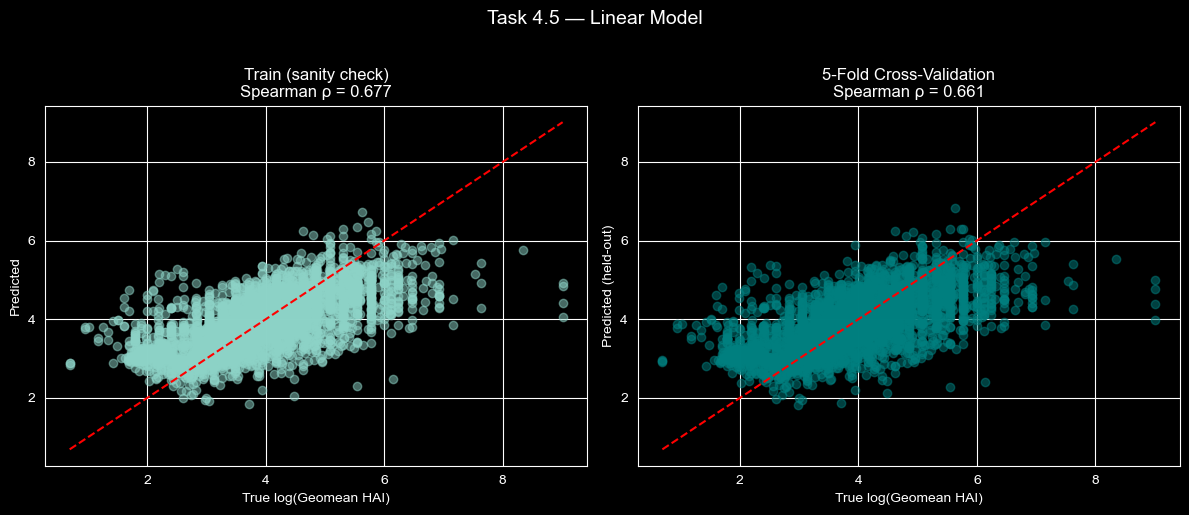

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: train predictions (sanity check)
axes[0].scatter(y_vals, y_pred_train, alpha=0.5)
axes[0].plot([y_vals.min(), y_vals.max()], [y_vals.min(), y_vals.max()], 'r--')
axes[0].set_xlabel('True log(Geomean HAI)')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Train (sanity check)\nSpearman ρ = {rho_train:.3f}')

# Right: cross-validated predictions (honest estimate)
axes[1].scatter(y_vals, y_pred_cv, alpha=0.5, color='teal')
axes[1].plot([y_vals.min(), y_vals.max()], [y_vals.min(), y_vals.max()], 'r--')
axes[1].set_xlabel('True log(Geomean HAI)')
axes[1].set_ylabel('Predicted (held-out)')
axes[1].set_title(f'5-Fold Cross-Validation\nSpearman ρ = {rho_cv:.3f}')

plt.suptitle('Task 4.5 — Linear Model', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Next Steps
- Incorporate Day 7 innate features (task description says they're allowed)
- Try regularized models (Ridge, Lasso) — helpful when the number of features is large relative to the number of samples
- Experiment with non-linear models (Random Forest, XGBoost) to capture interactions between features